In [1]:
# Standard library
import os  
from pathlib import Path  # Object-oriented filesystem paths

# Data handling packages
import numpy as np  
import numpy.random as npr  
import pandas as pd 
import pynwb
import ipywidgets as widgets
from IPython.display import display
import gc
import time
import sklearn

# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

from IPython.display import Image, display
import glob

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)
from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

# Plotting libraries
import matplotlib.pyplot as plt  
from matplotlib import colors  
import seaborn as sns  

# HMM-related imports from JAX, Dynamax, and TensorFlow Probability
from functools import partial
import jax.numpy as jnp
import jax.random as jr
from dynamax.hidden_markov_model import GaussianHMM
from dynamax.utils.utils import find_permutation

# Additional HMM variants and plotting utilities from Dynamax
from dynamax.hidden_markov_model import (
    DiagonalGaussianHMM,
    SphericalGaussianHMM,
    SharedCovarianceGaussianHMM
)

from dynamax.utils.plotting import CMAP, COLORS, white_to_color_cmap

# Pandas display settings
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline  


In [2]:
root = Path("/root/capsule/data/dynamicrouting_datacube")

example_session_ids = [
                        "759434_2025-02-04", "713655_2024-08-09", "743199_2024-12-05", 
                        "712815_2024-05-22", "742903_2024-10-23", "664851_2023-11-16", 
                        "741137_2024-10-10", "662892_2023-08-24", "714748_2024-06-24",
                        "667252_2023-09-28", "715710_2024-07-16", "708016_2024-04-29",
                    ]


session_id = example_session_ids[1] #session 4? mouse 4?

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb.zarr"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube/ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39/713655_2024-08-09.nwb.zarr


In [3]:
session = pynwb.read_nwb(nwb_path)

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (460263, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (460280, 500) float32 read-only>
  warnings.warn(


In [4]:
# QC thresholds from Shawn 

units_table = session.units.to_dataframe()


MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better
MAX_ACTIVITY_DRIFT = 0.2 # lower is better, moderate threshold

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO) & 
    (units_table.activity_drift < MAX_ACTIVITY_DRIFT)
]
print('%d of %d units passed quality control' % (len(good_units), len(units_table)))

1365 of 3577 units passed quality control


In [5]:
trials = session.trials[:]

In [13]:
trials.head()

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2403.42415,2408.92875,2403.42415,2404.89204,2404.93261,2405.43261,2405.00879,2405.92623,2405.47583,2405.46553,2405.49254,2405.953890,2408.956420,sound1,NaN,0,aud,0,0.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
1,2409.89623,2415.40125,2409.89623,2411.36411,2411.40501,2411.90501,2411.48088,2412.39832,2411.74797,2411.73257,2411.76447,2412.426005,2415.428515,sound1,NaN,0,aud,1,1.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
2,2417.98632,2423.49098,2417.98632,2419.45423,2419.49515,2419.99515,2419.57102,2420.48843,2420.03805,2420.03365,2420.05473,2420.516120,2423.518630,sound1,NaN,0,aud,2,2.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
3,2429.22911,2434.73372,2429.22911,2430.69701,2430.73779,2431.23779,2430.81378,2431.73118,2431.43094,2431.43076,2431.44765,2431.758880,2434.761390,sound1,NaN,0,aud,3,3.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
4,2435.43427,2440.93889,2435.43427,2436.90215,2436.94313,2437.44313,2437.01895,2437.93632,2437.60277,2437.60187,2437.61948,2437.964090,2440.966610,sound1,NaN,0,aud,4,4.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False


(array([222.,   0.,   0.,   0.,   5., 129.,   0.,   0.,   0., 159.]),
 array([1.50829 , 1.512037, 1.515784, 1.519531, 1.523278, 1.527025,
        1.530772, 1.534519, 1.538266, 1.542013, 1.54576 ]),
 <BarContainer object of 10 artists>)

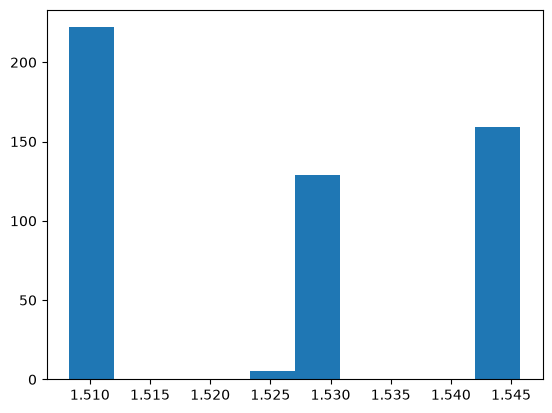

In [14]:
trial_times = trials['stop_time'] - trials['start_time']
stim_onset = trials['stim_start_time'] - trials['start_time']

plt.hist(stim_onset)

In [6]:
key1 = 'AUD'
key2 = 'CP'


area1_units = good_units[good_units['location'].str.contains(key1)]
area2_units = good_units[good_units['location'].str.contains(key2)]

In [11]:
from lda_vs_hmm_stimulus_decoding import run_context_split_comparison

# Sliding-window LDA vs. class-conditional HMM, run separately for:
#   - aud stimuli (sound1 vs sound2) decoded within the aud-rewarded block   (matched context)
#   - aud stimuli (sound1 vs sound2) decoded within the vis-rewarded block   (mismatched context)
#   - vis stimuli (vis1 vs vis2)     decoded within the vis-rewarded block   (matched context)
#   - vis stimuli (vis1 vs vis2)     decoded within the aud-rewarded block   (mismatched context)
# using area1_units (auditory cortex). Swap in area2_units to run the same
# comparison on CP units instead.
context_split_results = run_context_split_comparison(
    units_table, trials, area1_units['unit_id'],
    bin_size_s=0.05, t_pre_s=-0.5, t_post_s=1.5,
    window_bins=5, n_states=3, n_splits=5, n_restarts=2, n_iter=30,
    out_dir="/tmp",
)


=== aud stimuli (('sound1', 'sound2')) in aud-rewarded block (matched context) -- 118 trials ===
Decoding 2 stimulus classes (['sound1', 'sound2']) from 118 trials x 40 bins x 173 neurons, 5-fold CV.
Fitting sliding-window LDA...
Fitting per-class HMMs (this is the slow step: 2 classes x 5 folds x 2 restarts)...
Trial-averaged accuracy: LDA=0.880 HMM=0.810  (chance=0.500)
Paired Wilcoxon signed-rank test across 5 folds: stat=0.000, p=0.0625 -> LDA (not significant)
Figure written to /tmp/lda_vs_hmm_decode_accuracy_audstim_audblock.png

=== aud stimuli (('sound1', 'sound2')) in vis-rewarded block (mismatched context) -- 109 trials ===
Decoding 2 stimulus classes (['sound1', 'sound2']) from 109 trials x 40 bins x 173 neurons, 5-fold CV.
Fitting sliding-window LDA...
Fitting per-class HMMs (this is the slow step: 2 classes x 5 folds x 2 restarts)...
Trial-averaged accuracy: LDA=0.813 HMM=0.836  (chance=0.500)
Paired Wilcoxon signed-rank test across 5 folds: stat=0.000, p=0.0625 -> HMM (n

KeyboardInterrupt: 

In [ ]:
# Striatum data 

context_split_results = run_context_split_comparison(
    units_table, trials, area2_units['unit_id'],
    bin_size_s=0.05, t_pre_s=-0.5, t_post_s=1.5,
    window_bins=5, n_states=3, n_splits=5, n_restarts=2, n_iter=30,
    out_dir="/tmp",
)

In [13]:
import importlib
import sys

if "/root/capsule/code" not in sys.path:
    sys.path.insert(0, "/root/capsule/code")
import gpfa_yu2009
importlib.reload(gpfa_yu2009)
fit_gpfa_units = gpfa_yu2009.fit_gpfa_units

# Exclude catch trials before fitting so all plots use the same trial set.
analysis_trials = trials.loc[~trials["is_catch"].fillna(False)].copy()
print(f"Using {len(analysis_trials)} of {len(trials)} trials; catch trials excluded")

# Use a fixed event-aligned window: 0.5 seconds before stimulus onset
# through 1.5 seconds after stimulus onset.
result = fit_gpfa_units(
    area2_units,
    trials=analysis_trials,
    trial_onset_column="stim_start_time",
    t_pre_s=-0.5,
    t_post_s=1.5,
    bin_size_s=0.02,
    n_latent=3,
    warp_trials=False,
)

latent = result.latent_trajectories
print(f"latent trajectories: {latent.shape[0]} trials x {latent.shape[1]} bins x {latent.shape[2]} dimensions")

Using 460 of 515 trials; catch trials excluded
latent trajectories: 460 trials x 100 bins x 3 dimensions


In [24]:
import importlib
import gpfa_yu2009
importlib.reload(gpfa_yu2009)

<module 'gpfa_yu2009' from '/root/capsule/code/gpfa_yu2009.py'>

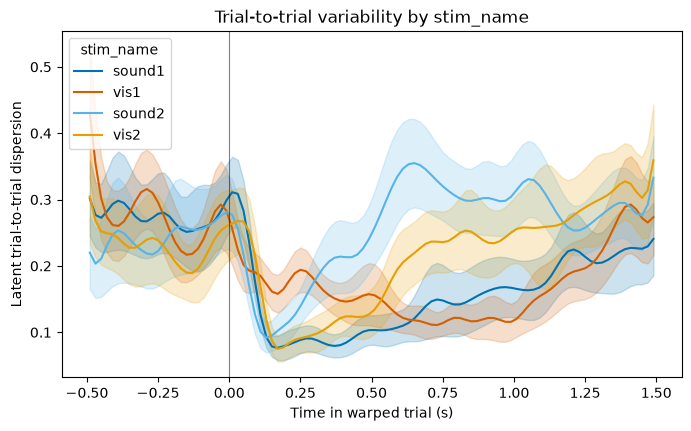

,n_trials,mean_latent_dispersion
sound1,118.0,0.185168
vis1,125.0,0.196481
sound2,109.0,0.255344
vis2,108.0,0.219962


In [14]:
from gpfa_yu2009 import plot_trial_variability

# Choose the grouping variable here:
#   "stim_name" for stimulus comparisons
#   "rewarded_modality" for context-block comparisons
condition_column = "stim_name"
condition_labels = analysis_trials[condition_column].to_numpy()
stimulus_colors = {
    "sound1": "#0072B2",
    "sound2": "#56B4E9",
    "vis1": "#D55E00",
    "vis2": "#E69F00",
}

variability_ax, variability_summary = plot_trial_variability(
    result,
    condition_labels=condition_labels,
    condition_name=condition_column,
    colors=stimulus_colors,
)
plt.show()

pd.DataFrame({
    label: {
        "n_trials": values["n_trials"],
        "mean_latent_dispersion": values["mean_dispersion"],
    }
    for label, values in variability_summary.items()
}).T

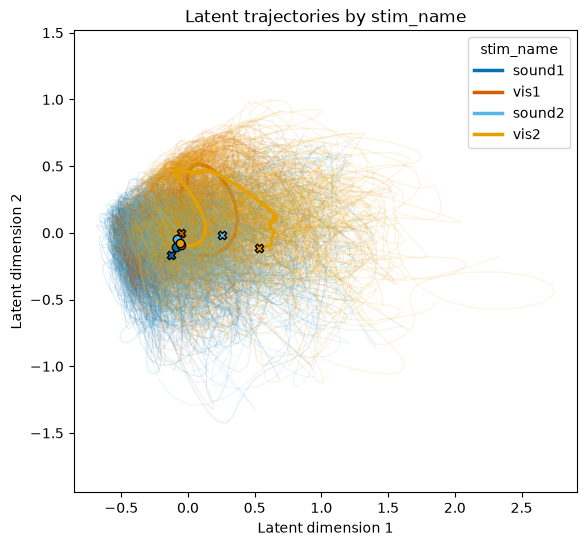

,n_trials,integrated_path_length
sound1,118.0,1.490444
vis1,125.0,2.390401
sound2,109.0,1.479738
vis2,108.0,2.382524


In [15]:
from gpfa_yu2009 import plot_latent_trajectories

trajectory_ax, trajectory_summary = plot_latent_trajectories(
    result,
    condition_labels=condition_labels,
    dimensions=(0, 1),
    condition_name=condition_column,
    colors=stimulus_colors,
)
plt.show()

pd.DataFrame({
    label: {
        "n_trials": values["n_trials"],
        "integrated_path_length": values["integrated_path_length"],
    }
    for label, values in trajectory_summary.items()
}).T

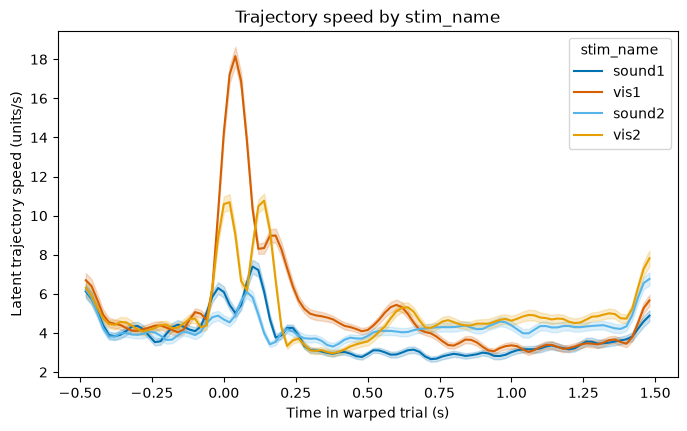

,n_trials,mean_speed_over_time
sound1,118.0,3.793197
vis1,125.0,5.187164
sound2,109.0,4.293113
vis2,108.0,5.003143


In [16]:
from gpfa_yu2009 import plot_trajectory_speed, compute_trajectory_speed

speed_ax, speed_result = plot_trajectory_speed(
    result,
    condition_labels=condition_labels,
    condition_name=condition_column,
    colors=stimulus_colors,
)
plt.show()

speed_summary = pd.DataFrame({
    label: {
        "n_trials": values["n_trials"],
        "mean_speed_over_time": values["mean_speed_over_time"],
    }
    for label, values in speed_result["by_condition"].items()
}).T
speed_summary

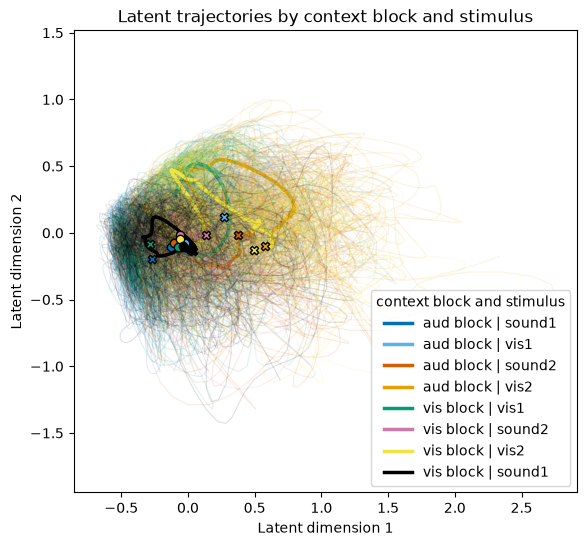

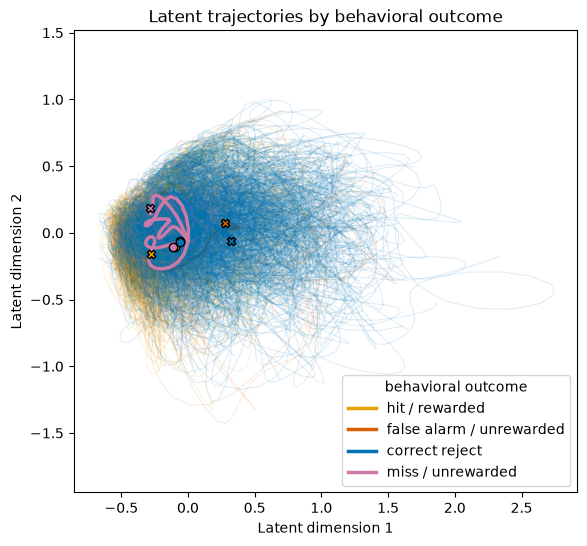

Behavioral comparison includes 460 classified trials


In [17]:
# Show stimulus-specific trajectories within each rewarded context block.
block_labels = analysis_trials["rewarded_modality"].astype(str).to_numpy()
stimulus_names = analysis_trials["stim_name"].astype(str).to_numpy()
block_stim_labels = np.array([
    f"{block} block | {stimulus}"
    for block, stimulus in zip(block_labels, stimulus_names)
])
block_stim_values = list(dict.fromkeys(block_stim_labels.tolist()))
block_stim_palette = [
    "#0072B2", "#56B4E9", "#D55E00", "#E69F00",
    "#009E73", "#CC79A7", "#F0E442", "#000000",
]
block_stim_colors = {
    label: block_stim_palette[index % len(block_stim_palette)]
    for index, label in enumerate(block_stim_values)
}

block_stim_ax, block_stim_summary = plot_latent_trajectories(
    result,
    condition_labels=block_stim_labels,
    dimensions=(0, 1),
    condition_name="context block and stimulus",
    colors=block_stim_colors,
)
plt.show()

# Compare all non-catch behavioral outcomes.
outcome_conditions = [
    ("is_hit", "hit / rewarded"),
    ("is_correct_reject", "correct reject"),
    ("is_miss", "miss / unrewarded"),
    ("is_false_alarm", "false alarm / unrewarded"),
]
outcome_labels = np.full(len(analysis_trials), "unclassified", dtype=object)
for column, label in outcome_conditions:
    outcome_labels[analysis_trials[column].fillna(False).to_numpy()] = label
outcome_mask = outcome_labels != "unclassified"

outcome_result = gpfa_yu2009.GPFAResult(
    latent_trajectories=result.latent_trajectories[outcome_mask],
    time=result.time,
    spike_counts=result.spike_counts[outcome_mask],
    unit_ids=result.unit_ids,
    model=result.model,
)
outcome_colors = {
    "hit / rewarded": "#E69F00",
    "correct reject": "#0072B2",
    "miss / unrewarded": "#CC79A7",
    "false alarm / unrewarded": "#D55E00",
}
outcome_ax, outcome_summary = plot_latent_trajectories(
    outcome_result,
    condition_labels=outcome_labels[outcome_mask],
    dimensions=(0, 1),
    condition_name="behavioral outcome",
    colors=outcome_colors,
)
plt.show()

print(f"Behavioral comparison includes {outcome_mask.sum()} classified trials")